# Deep Learning para NLP — *El Quijote*

**Duración estimada:** ~2 horas  
**Nivel:** Intermedio  
**Requisitos:** Python, nociones de redes neuronales

En este notebook construimos **tres modelos** sobre el mismo corpus — *El ingenioso hidalgo don Quijote de la Mancha* — para entender cómo evoluciona el NLP basado en deep learning:

1. **RNN vanilla** — generación de texto a nivel de carácter.
2. **LSTM** — resuelve los gradientes que desaparecen y aprende dependencias largas.
3. **Autoencoder de bloques** — aprende a **comprimir y reconstruir párrafos completos** como un vector de tamaño fijo, y con un **decoder generativo** acoplado produce texto condicionado al latente.

Al final comparamos qué hace cada uno y por qué.

---

## Agenda

| Bloque | Tema |
|--------|------|
| 0 | Instalación y descarga del corpus |
| 1 | Preparar el corpus de *El Quijote* |
| 2 | Tokenización a nivel de carácter (RNN/LSTM) |
| 3 | RNN vanilla para generación |
| 4 | LSTM para generación |
| 5 | Autoencoder de bloques de texto (BoW) + decoder generativo sobre el latente |
| 6 | Comparación y cierre |

---
## 0. Instalación de dependencias

In [1]:
!uv pip install torch numpy matplotlib requests scikit-learn

Using Python 3.11.13 environment at: /home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv
Audited 5 packages in 23ms


In [2]:
import os
import re
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)
print('PyTorch:', torch.__version__)

Dispositivo: cuda
PyTorch: 2.11.0+cu130


---
## 1. El corpus: *Don Quijote de la Mancha*

Descargamos el texto completo desde [Project Gutenberg](https://www.gutenberg.org/cache/epub/2000/pg2000.txt) — una versión libre de derechos de autor.

In [3]:
QUIJOTE_URL = 'https://www.gutenberg.org/cache/epub/2000/pg2000.txt'
CACHE_PATH = 'quijote.txt'

if not os.path.exists(CACHE_PATH):
    print('Descargando Don Quijote…')
    r = requests.get(QUIJOTE_URL, timeout=30)
    r.encoding = 'utf-8'
    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        f.write(r.text)
    print('Descarga completa.')

with open(CACHE_PATH, 'r', encoding='utf-8') as f:
    raw = f.read()

print(f'Caracteres totales: {len(raw):,}')
print('\n--- primeras 500 char ---')
print(raw[:500])

Caracteres totales: 2,130,058

--- primeras 500 char ---
﻿The Project Gutenberg eBook of Don Quijote
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: 


### 1.1 Limpiar el encabezado/pie de Gutenberg y normalizar

Project Gutenberg rodea el texto con marcadores `*** START OF … ***` y `*** END OF … ***`. Los recortamos.

In [4]:
m_ini = re.search(r'\*\*\*\s*START OF.*?\*\*\*', raw)
m_fin = re.search(r'\*\*\*\s*END OF.*?\*\*\*', raw)
texto = raw[m_ini.end():m_fin.start()] if (m_ini and m_fin) else raw

# Normalizaciones ligeras
texto = texto.replace('\r\n', '\n')
texto = re.sub(r'\n{3,}', '\n\n', texto)  # compactar saltos de línea
texto = texto.lower()
# Mantener solo letras (incluyendo español), dígitos, espacios y puntuación básica
texto = re.sub(r'[^a-z0-9áéíóúüñ¿¡\.\,\;\:\!\?\-\' \"\n]', ' ', texto)
texto = re.sub(r' +', ' ', texto)

# Cortamos el texto solo para RNN/LSTM (entrenamiento rápido char-level).
# El autoencoder de bloques usará el texto COMPLETO (sección 5).
texto_completo = texto
N_CHARS = 200_000
texto = texto[:N_CHARS]

print(f'Caracteres (texto_completo): {len(texto_completo):,}')
print(f'Caracteres (ventana RNN/LSTM): {len(texto):,}')
print('\n--- muestra ---')
print(texto[200:900])

Caracteres (texto_completo): 2,104,762
Caracteres (ventana RNN/LSTM): 200,000

--- muestra ---
prólogo

 
al libro de don quijote de la mancha

que trata de la condición y ejercicio del famoso
hidalgo don quijote de la mancha

que trata de la primera salida que de su tierra hizo
el ingenioso don quijote

donde se cuenta la graciosa manera que tuvo don
quijote en armarse caballero

de lo que le sucedió a nuestro caballero cuando salió
de la venta

donde se prosigue la narración de la desgracia de
nuestro caballero

del donoso y grande escrutinio que el cura y el
barbero hicieron en la librería de nuestro ingenioso hidalgo

de la segunda salida de nuestro buen caballero don
quijote de la mancha

del buen suceso que el valeroso don quijote tuvo en
la espantable y jamás imaginada aventura


---
## 2. Tokenización a nivel de carácter (para RNN y LSTM)

Trabajaremos **char-level** para simplificar. El vocabulario es pequeño (~50 símbolos) y evitamos problemas de palabras fuera del diccionario.

In [5]:
chars = sorted(set(texto))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

print(f'Vocabulario: {vocab_size} caracteres')
print('Símbolos:', ''.join(chars).replace('\n', '\\n'))

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join(itos[int(i)] for i in ids)

data = torch.tensor(encode(texto), dtype=torch.long)
print(f'Tensor de datos: shape={tuple(data.shape)}, dtype={data.dtype}')

Vocabulario: 48 caracteres
Símbolos: \n !"',-.0146:;?abcdefghijlmnopqrstuvxyz¡¿áéíñóúü
Tensor de datos: shape=(200000,), dtype=torch.int64


### 2.1 Train/validation split y dataset

In [6]:
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f'Train: {len(train_data):,} chars')
print(f'Val  : {len(val_data):,} chars')

SEQ_LEN = 64   # contexto
BATCH_SIZE = 128

def get_batch(split='train'):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(len(src) - SEQ_LEN - 1, (BATCH_SIZE,))
    x = torch.stack([src[i:i+SEQ_LEN]     for i in ix])
    y = torch.stack([src[i+1:i+SEQ_LEN+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print('batch x:', xb.shape, ' | batch y:', yb.shape)
print('ejemplo x[0]:', repr(decode(xb[0].tolist())[:80]))
print('ejemplo y[0]:', repr(decode(yb[0].tolist())[:80]))

Train: 180,000 chars
Val  : 20,000 chars
batch x: torch.Size([128, 64])  | batch y: torch.Size([128, 64])
ejemplo x[0]: 'nte. y así,\n¿qué podrá engendrar el estéril y mal cultivado inge'
ejemplo y[0]: 'te. y así,\n¿qué podrá engendrar el estéril y mal cultivado ingen'


---
## 3. RNN vanilla — primer modelo

Una **RNN vanilla** (Elman) mantiene un estado oculto `h_t` y lo actualiza con:

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
$$\hat{y}_t = W_{hy} h_t + b_y$$

PyTorch la implementa directamente en `nn.RNN`.

In [7]:
class RNNCharLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        e = self.embed(x)                # (B, T, E)
        out, h = self.rnn(e, h)          # (B, T, H)
        logits = self.head(out)          # (B, T, V)
        return logits, h

    @torch.no_grad()
    def generar(self, prompt, max_new=300, temperatura=1.0):
        self.eval()
        ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
        h = None
        for _ in range(max_new):
            logits, h = self(ids[:, -1:], h) if ids.size(1) > 0 else self(ids, h)
            logits = logits[:, -1, :] / max(temperatura, 1e-6)
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            ids = torch.cat([ids, next_id], dim=1)
        return decode(ids[0].tolist())

rnn_model = RNNCharLM(vocab_size).to(device)
print(rnn_model)
n_params = sum(p.numel() for p in rnn_model.parameters())
print(f'Parámetros: {n_params:,}')

RNNCharLM(
  (embed): Embedding(48, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (head): Linear(in_features=128, out_features=48, bias=True)
)
Parámetros: 34,096


### 3.1 Bucle de entrenamiento genérico

Usaremos una función compartida para RNN y LSTM.

In [8]:
def entrenar_lm(modelo, pasos=2000, lr=3e-3, eval_cada=200):
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr)
    hist_train, hist_val, iters = [], [], []
    t0 = time.time()
    for it in range(1, pasos + 1):
        modelo.train()
        xb, yb = get_batch('train')
        logits, _ = modelo(xb)
        loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        opt.step()

        if it % eval_cada == 0 or it == 1:
            modelo.eval()
            with torch.no_grad():
                xvb, yvb = get_batch('val')
                vlogits, _ = modelo(xvb)
                vloss = F.cross_entropy(vlogits.view(-1, vocab_size), yvb.view(-1))
            hist_train.append(loss.item())
            hist_val.append(vloss.item())
            iters.append(it)
            print(f'step {it:5d} | train {loss.item():.3f} | val {vloss.item():.3f} | {time.time()-t0:5.1f}s')
    return {'iters': iters, 'train': hist_train, 'val': hist_val}

In [9]:
hist_rnn = entrenar_lm(rnn_model, pasos=2000, lr=3e-3, eval_cada=200)

step     1 | train 3.866 | val 3.667 |   0.3s
step   200 | train 1.773 | val 1.765 |   1.0s
step   400 | train 1.620 | val 1.670 |   1.6s
step   600 | train 1.518 | val 1.635 |   2.3s
step   800 | train 1.445 | val 1.607 |   2.9s
step  1000 | train 1.467 | val 1.586 |   3.6s
step  1200 | train 1.431 | val 1.579 |   4.3s
step  1400 | train 1.450 | val 1.563 |   5.0s
step  1600 | train 1.399 | val 1.551 |   5.7s
step  1800 | train 1.441 | val 1.570 |   6.4s
step  2000 | train 1.418 | val 1.617 |   7.3s


### 3.2 Generar texto con la RNN

In [10]:
for temp in [0.5, 0.8, 1.2]:
    print(f'\n=== RNN — temperatura {temp} ===')
    print(rnn_model.generar('en un lugar de la mancha', max_new=300, temperatura=temp))


=== RNN — temperatura 0.5 ===
en un lugar de la manchando la memoria de su espada, y de mancha, que había por acomodado la noche, y grande de comenzó a esta a duisa y que con las caballeros, y será acometido a los compañero que la demás de las arriero a los ojos de su abrieron los armas, que el barbero de la batalle en el cura no se nos muchacho respon

=== RNN — temperatura 0.8 ===
en un lugar de la mancha realer, trata de la cantante, que en esto, que con famosa en el que si me desio
estaban de mancia que se andante en el barbezando sancho, y de la vienda vez para que el amores, que levantene se
hacer mismertiva de las raguntó a caballero que los molinando en las mestoria de unas costa estrañas que 

=== RNN — temperatura 1.2 ===
en un lugar de la manchan. no primero parte,
el aun solo nombre me hasta de toda lo que era gobernatría
un hucho, de manera que el mundo estaba bien le trabado.

y mez la
gran
lerdufra, y, avucíada y lagogantes, no el dos aquel coborro el había rondineía, e

### 3.3 Limitaciones de la RNN

La RNN vanilla sufre el **gradiente que desaparece** (o que explota): al propagar hacia atrás en el tiempo, las dependencias largas se borran. En texto, esto significa que olvida el principio de la oración antes de terminarla.

La solución: **LSTM**.

---
## 4. LSTM — dependencias más largas

La **Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) añade una **célula de memoria** `c_t` y **compuertas** que controlan qué información entra, sale o se olvida:

- Forget gate `f_t`
- Input gate `i_t`
- Candidate `g_t`
- Output gate `o_t`

Esto permite que la información fluya a lo largo de muchos timesteps sin desvanecerse.

In [11]:
class LSTMCharLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=192, num_layers=2, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        e = self.embed(x)
        out, state = self.lstm(e, state)
        logits = self.head(out)
        return logits, state

    @torch.no_grad()
    def generar(self, prompt, max_new=300, temperatura=1.0, top_k=None):
        self.eval()
        ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
        state = None
        # "warm-up" con el prompt completo
        logits, state = self(ids, state)
        for _ in range(max_new):
            logits_last = logits[:, -1, :] / max(temperatura, 1e-6)
            if top_k is not None:
                v, _ = torch.topk(logits_last, top_k)
                logits_last[logits_last < v[:, [-1]]] = -float('inf')
            probs = F.softmax(logits_last, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            ids = torch.cat([ids, next_id], dim=1)
            logits, state = self(next_id, state)
        return decode(ids[0].tolist())

lstm_model = LSTMCharLM(vocab_size).to(device)
print(lstm_model)
n_params = sum(p.numel() for p in lstm_model.parameters())
print(f'Parámetros: {n_params:,}')

LSTMCharLM(
  (embed): Embedding(48, 64)
  (lstm): LSTM(64, 192, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=192, out_features=48, bias=True)
)
Parámetros: 506,928


In [12]:
hist_lstm = entrenar_lm(lstm_model, pasos=3000, lr=2e-3, eval_cada=300)

step     1 | train 3.877 | val 3.826 |   0.1s
step   300 | train 1.733 | val 1.739 |  11.2s
step   600 | train 1.574 | val 1.593 |  22.4s
step   900 | train 1.431 | val 1.533 |  33.8s
step  1200 | train 1.346 | val 1.486 |  44.9s
step  1500 | train 1.255 | val 1.521 |  55.9s
step  1800 | train 1.243 | val 1.489 |  66.8s
step  2100 | train 1.183 | val 1.435 |  77.8s
step  2400 | train 1.117 | val 1.521 |  88.8s
step  2700 | train 1.089 | val 1.495 | 100.5s
step  3000 | train 1.051 | val 1.497 | 112.0s


### 4.1 Generar texto con la LSTM

In [13]:
for temp in [0.5, 0.8, 1.2]:
    print(f'\n=== LSTM — temperatura {temp} ===')
    print(lstm_model.generar('en un lugar de la mancha', max_new=300, temperatura=temp, top_k=20))


=== LSTM — temperatura 0.5 ===
en un lugar de la mancha, le dijo:

 señor caballero, que en esto, cuando llegará al cual visto por el castillo de dicho para que aquí le dejasen del alcanzar la vida de la mancha

de lo que estaba de su mala, dejando lo que por agora, y de estaba y le dijo:

 ¿qué es esta las manos de las armas de la mancha, con otros suc

=== LSTM — temperatura 0.8 ===
en un lugar de la mancha

de lo mesmo respondió el barbero ; play sino fue las del cumplir el rico vizcaíno y a su escudero, y lo dejaban temor, porque, a caminar que don quijote con razón compadre, no para que con su españa, y la orden de cortarse, con otros sucesos del molimento en el juez, que en un solo que te más que 

=== LSTM — temperatura 1.2 ===
en un lugar de la mancha, habimióte que te faltaba
al pasó un poco se vio un porque la malididad a onte velar a sí mancha, es pedquisto. mas, pues, que le dejó don quijote, llegó a los
caballeros
andantes, sino faltaba de ella baja, o que de mí dalánzose

### 4.2 Comparar curvas de aprendizaje

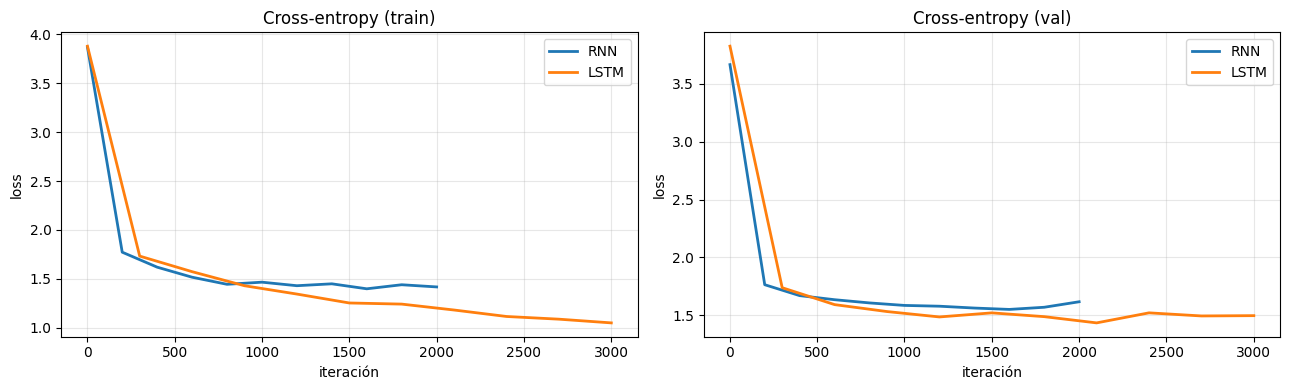

Pérdida val final:
  RNN : 1.617
  LSTM: 1.497


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'val']):
    ax.plot(hist_rnn['iters'],  hist_rnn[split],  label='RNN',  lw=2)
    ax.plot(hist_lstm['iters'], hist_lstm[split], label='LSTM', lw=2)
    ax.set_title(f'Cross-entropy ({split})')
    ax.set_xlabel('iteración')
    ax.set_ylabel('loss')
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print('Pérdida val final:')
print(f"  RNN : {hist_rnn['val'][-1]:.3f}")
print(f"  LSTM: {hist_lstm['val'][-1]:.3f}")

---
## 5. Autoencoder de bloques de texto

Cambiamos de paradigma. La RNN y la LSTM procesan el texto **secuencialmente**, carácter a carácter. Aquí haremos algo distinto: **tomamos un bloque de texto entero** (un párrafo o fragmento del Quijote), lo representamos como **un único vector de tamaño fijo** y entrenamos una red neuronal **densa** (no recurrente) para comprimirlo y reconstruirlo.

```
          bloque de texto
                │
                ▼
     [Bag-of-Words / TF-IDF]   ← vector de tamaño V (vocabulario)
                │
                ▼
       Encoder (MLP: V → h → z)
                │
                ▼   ← z ∈ ℝ^d  (representación comprimida del bloque)
                │
                ▼
       Decoder (MLP: z → h → V)
                │
                ▼
        vector BoW reconstruido
```

**Por qué es interesante:**

- Es una **compresión no-lineal aprendida** — la variante neuronal del PCA.
- El vector `z` funciona como un **embedding del bloque entero**.
- Permite **búsqueda semántica** entre bloques.
- Es la base conceptual de ideas como *Semantic Hashing* (Hinton & Salakhutdinov, 2009) y de muchos sistemas modernos de retrieval.

### 5.1 Segmentar el Quijote en bloques

Ahora usamos el **texto completo** (no solo la ventana de 200K chars). Dividimos en **bloques** de tamaño comparable — un bloque agrupa una o más frases hasta llegar a una longitud razonable.

In [15]:
def segmentar_bloques(texto, min_palabras=30, max_palabras=120):
    """Corta el texto en bloques con longitud entre min y max palabras."""
    parrafos = [p.strip() for p in re.split(r'\n\s*\n', texto) if p.strip()]
    bloques = []
    buffer, count = [], 0
    for p in parrafos:
        n = len(p.split())
        if n < min_palabras:
            buffer.append(p); count += n
            if count >= min_palabras:
                bloques.append(' '.join(buffer)); buffer, count = [], 0
        elif n <= max_palabras:
            if buffer:
                bloques.append(' '.join(buffer)); buffer, count = [], 0
            bloques.append(p)
        else:
            if buffer:
                bloques.append(' '.join(buffer)); buffer, count = [], 0
            palabras = p.split()
            for i in range(0, len(palabras), max_palabras):
                bloques.append(' '.join(palabras[i:i+max_palabras]))
    if buffer:
        bloques.append(' '.join(buffer))
    return bloques

bloques = segmentar_bloques(texto_completo)
longitudes = [len(b.split()) for b in bloques]
print(f'Bloques totales: {len(bloques):,}')
print(f'Longitud media: {np.mean(longitudes):.1f} palabras')
print(f'Longitud min/max: {min(longitudes)} / {max(longitudes)}')
print('\n--- ejemplo de bloque ---')
print(bloques[10][:500])

Bloques totales: 5,951
Longitud media: 64.7 palabras
Longitud min/max: 1 / 120

--- ejemplo de bloque ---
de la jamás vista ni oída aventura que con más poco
peligro fue acabada de famoso caballero en el mundo, como la que acabó
el valeroso don quijote de la mancha


### 5.2 Representar cada bloque como un vector TF-IDF

Cada bloque se convierte en un vector de tamaño fijo `V` (tamaño del vocabulario). Usamos **TF-IDF** limitado a las palabras más frecuentes para que `V` sea manejable.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

V_BOW = 3000   # dimensión del vector BoW — controla el tamaño del autoencoder

vectorizer = TfidfVectorizer(
    max_features=V_BOW,
    min_df=3,           # palabras que aparecen en al menos 3 bloques
    max_df=0.8,         # descarta palabras en más del 80% de bloques
    token_pattern=r'[a-záéíóúüñ]{3,}',  # solo palabras con letras, 3+ caracteres
)
X = vectorizer.fit_transform(bloques).toarray().astype(np.float32)
vocab_bow = vectorizer.get_feature_names_out()

print(f'Matriz TF-IDF: {X.shape}  (bloques × palabras)')
print(f'Dimensión del vocabulario: {len(vocab_bow)}')
print(f'Palabras no-nulas promedio por bloque: {(X > 0).sum(axis=1).mean():.1f}')

Matriz TF-IDF: (5951, 3000)  (bloques × palabras)
Dimensión del vocabulario: 3000
Palabras no-nulas promedio por bloque: 29.8


In [17]:
# Split train/val
rng = np.random.RandomState(42)
idx = rng.permutation(len(X))
sp = int(0.9 * len(X))
idx_train, idx_val = idx[:sp], idx[sp:]

X_train = torch.tensor(X[idx_train])
X_val   = torch.tensor(X[idx_val])
bloques_val = [bloques[i] for i in idx_val]

print(f'Train bloques: {len(X_train):,}')
print(f'Val   bloques: {len(X_val):,}')

class BlockDataset(Dataset):
    def __init__(self, X): self.X = X
    def __len__(self):      return len(self.X)
    def __getitem__(self, i): return self.X[i]

train_loader = DataLoader(BlockDataset(X_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(BlockDataset(X_val),   batch_size=64)

Train bloques: 5,355
Val   bloques: 596


### 5.3 Arquitectura del autoencoder

**MLP** simétrico, sin recurrencia. Entrada y salida son vectores de tamaño `V_BOW`; en el medio hay un **cuello de botella** de dimensión `d` (mucho menor que `V_BOW`).

In [18]:
class BlockAutoencoder(nn.Module):
    def __init__(self, V, h=512, d=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(V, h), nn.ReLU(),
            nn.Linear(h, h // 2), nn.ReLU(),
            nn.Linear(h // 2, d),  # cuello de botella
        )
        self.decoder = nn.Sequential(
            nn.Linear(d, h // 2), nn.ReLU(),
            nn.Linear(h // 2, h), nn.ReLU(),
            nn.Linear(h, V),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

D_LATENT = 64
ae = BlockAutoencoder(V=X.shape[1], h=512, d=D_LATENT).to(device)
print(ae)
print(f'Parámetros: {sum(p.numel() for p in ae.parameters()):,}')
print(f'Compresión: {X.shape[1]} → {D_LATENT}  ({D_LATENT/X.shape[1]*100:.1f}% del tamaño original)')

BlockAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3000, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=3000, bias=True)
  )
)
Parámetros: 3,371,512
Compresión: 3000 → 64  (2.1% del tamaño original)


### 5.4 Entrenar

La pérdida es **MSE** entre el vector TF-IDF original y su reconstrucción. El autoencoder aprende a preservar la información más importante del bloque en solo `d` dimensiones.

In [19]:
def entrenar_autoencoder(modelo, epochs=40, lr=1e-3):
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.MSELoss()
    hist_train, hist_val = [], []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        modelo.train(); losses = []
        for xb in train_loader:
            xb = xb.to(device)
            x_hat, _ = modelo(xb)
            loss = crit(x_hat, xb)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            losses.append(loss.item())
        modelo.eval(); vlosses = []
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                x_hat, _ = modelo(xb)
                vlosses.append(crit(x_hat, xb).item())
        hist_train.append(float(np.mean(losses)))
        hist_val.append(float(np.mean(vlosses)))
        if ep % 5 == 0 or ep == 1:
            print(f'epoch {ep:3d}/{epochs} | train {hist_train[-1]:.5f} | val {hist_val[-1]:.5f} | {time.time()-t0:5.1f}s')
    return {'train': hist_train, 'val': hist_val}

hist_ae = entrenar_autoencoder(ae, epochs=40, lr=1e-3)

epoch   1/40 | train 0.00035 | val 0.00032 |   0.2s
epoch   5/40 | train 0.00031 | val 0.00031 |   1.0s
epoch  10/40 | train 0.00029 | val 0.00030 |   1.9s
epoch  15/40 | train 0.00028 | val 0.00029 |   2.9s
epoch  20/40 | train 0.00027 | val 0.00028 |   3.8s
epoch  25/40 | train 0.00027 | val 0.00028 |   4.8s
epoch  30/40 | train 0.00026 | val 0.00028 |   5.7s
epoch  35/40 | train 0.00025 | val 0.00028 |   6.7s
epoch  40/40 | train 0.00025 | val 0.00028 |   7.6s


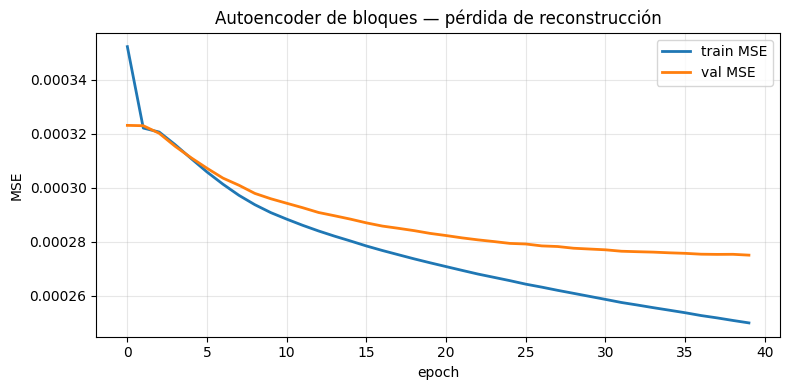

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(hist_ae['train'], lw=2, label='train MSE')
plt.plot(hist_ae['val'],   lw=2, label='val MSE')
plt.xlabel('epoch'); plt.ylabel('MSE')
plt.title('Autoencoder de bloques — pérdida de reconstrucción')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

### 5.5 ¿Qué reconstruye el modelo?

El vector reconstruido vive en el espacio TF-IDF. Para ver qué "recuerda" del bloque, inspeccionamos las **palabras con mayor peso** en la reconstrucción y las comparamos con las del bloque original.

In [21]:
def top_palabras(vector, vocab, k=10):
    idx_sorted = np.argsort(-vector)
    return [(vocab[i], float(vector[i])) for i in idx_sorted[:k] if vector[i] > 1e-4]

ae.eval()
with torch.no_grad():
    x_hat, _ = ae(X_val[:6].to(device))
    x_hat = x_hat.cpu().numpy()

for i in range(4):
    print(f'\n=== Bloque {i} ===')
    print('TEXTO ORIGINAL:')
    print(f'  {bloques_val[i][:280]}...')
    orig  = top_palabras(X_val[i].numpy(), vocab_bow, k=8)
    recon = top_palabras(x_hat[i],         vocab_bow, k=8)
    print('Palabras top (originales)   :', [w for w, _ in orig])
    print('Palabras top (reconstruidas):', [w for w, _ in recon])


=== Bloque 0 ===
TEXTO ORIGINAL:
  el rey mi padre, que se llama tinacrio el sabidor, fue muy docto en esto que llaman el arte mágica, y alcanzó por su ciencia que mi madre, que se llamaba la reina jaramilla, había de morir primero que él, y que de allí a poco tiempo él también había de pasar desta vida y yo había...
Palabras top (originales)   : ['madre', 'había', 'padre', 'cosa', 'descomunal', 'muy', 'alcanzó', 'arte']
Palabras top (reconstruidas): ['había', 'porque', 'por', 'señor', 'muy', 'fue', 'una', 'esto']

=== Bloque 1 ===
TEXTO ORIGINAL:
  con todo eso, hermano y señor dijo el del bosque , si el ciego guía al
ciego, ambos van a peligro de caer en el hoyo. mejor es retirarnos con buen
compás de pies, y volvernos a nuestras querencias; que los que buscan
aventuras no siempre las hallan buenas....
Palabras top (originales)   : ['ciego', 'compás', 'guía', 'nuestras', 'van', 'caer', 'bosque', 'peligro']
Palabras top (reconstruidas): ['con', 'del', 'dijo', 'eso', 'todo', 'las', 'l

El autoencoder **no memoriza** el bloque — lo **resume**: conserva las palabras clave más distintivas (las que tenían más peso TF-IDF). Esto es la firma de una buena compresión.

### 5.6 Métrica: precision@k

¿Cuántas de las top-`k` palabras del bloque original aparecen entre las top-`k` de su reconstrucción?

In [22]:
ae.eval()
with torch.no_grad():
    x_hat_full, _ = ae(X_val.to(device))
    x_hat_full = x_hat_full.cpu().numpy()

def precision_at_k(x_true, x_pred, k=10):
    top_true = set(np.argsort(-x_true)[:k])
    top_pred = set(np.argsort(-x_pred)[:k])
    return len(top_true & top_pred) / k

for k in [5, 10, 20, 50]:
    ps = [precision_at_k(X_val[i].numpy(), x_hat_full[i], k=k)
          for i in range(len(X_val))]
    print(f'Precision@{k:<3d} = {np.mean(ps):.3f}')

Precision@5   = 0.158
Precision@10  = 0.189
Precision@20  = 0.259
Precision@50  = 0.267


### 5.7 El espacio latente

Cada bloque queda representado por un vector `z ∈ ℝ^64`. Proyectamos a 2D con PCA y coloreamos por **posición del bloque en el libro** para ver si aparece estructura narrativa.

Espacio latente: (5951, 64)


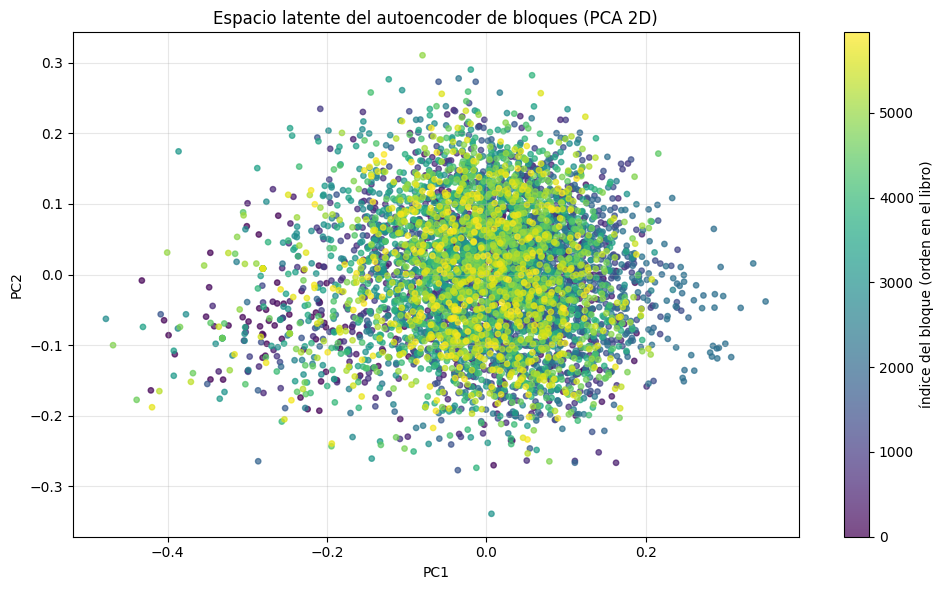

In [23]:
from sklearn.decomposition import PCA

ae.eval()
with torch.no_grad():
    Z_all = ae.encoder(torch.tensor(X).to(device)).cpu().numpy()
print(f'Espacio latente: {Z_all.shape}')

Z2 = PCA(n_components=2, random_state=42).fit_transform(Z_all)
posiciones = np.arange(len(Z2))

plt.figure(figsize=(10, 6))
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=posiciones, cmap='viridis', s=15, alpha=0.7)
plt.colorbar(sc, label='índice del bloque (orden en el libro)')
plt.title('Espacio latente del autoencoder de bloques (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 5.8 Búsqueda por similitud entre bloques

Dado un bloque cualquiera, encontramos los más parecidos usando **distancia coseno** en el espacio latente `z`. Esto es exactamente lo que hace un sistema de **retrieval** moderno — pero nosotros lo construimos desde cero.

In [24]:
from numpy.linalg import norm

def bloques_similares(idx_query, k=4):
    zq = Z_all[idx_query]
    sims = (Z_all @ zq) / (norm(Z_all, axis=1) * norm(zq) + 1e-9)
    sims[idx_query] = -1   # excluirse a sí mismo
    top = np.argsort(-sims)[:k]
    return [(i, sims[i]) for i in top]

for idx_query in [50, 150, 400, 900]:
    if idx_query >= len(bloques):
        continue
    print(f'\n>>> Bloque de consulta #{idx_query}:')
    print(f'  {bloques[idx_query][:220]}...')
    print('\n  Bloques más parecidos:')
    for i, sim in bloques_similares(idx_query, k=3):
        print(f'  [sim={sim:.3f}] {bloques[i][:180]}...')
    print('-' * 80)


>>> Bloque de consulta #50:
  donde se prosigue cómo se portaba sancho panza en
su gobierno de lo que le sucedió a don quijote con doña
rodríguez, la dueña de la duquesa, con otros acontecimientos dignos de
escritura y de memoria eterna...

  Bloques más parecidos:
  [sim=0.875] capítulo xlviii. de lo que le sucedió a don quijote con doña rodríguez, la
dueña de la duquesa, con otros acontecimientos dignos de escritura y de
memoria eterna...
  [sim=0.756] del progreso del gobierno de sancho panza, con otros
sucesos tales como buenos donde se cuenta la aventura de la segunda dueña
dolorida, o angustiada, llamada por otro nombre doña ...
  [sim=0.632] capítulo xxxvi. donde se cuenta la estraña y jamás imaginada aventura de la
dueña dolorida, alias de la condesa trifaldi, con una carta que sancho
panza escribió a su mujer teresa ...
--------------------------------------------------------------------------------

>>> Bloque de consulta #150:
  de mí a su talante''?...

  Bloques más parec

### 5.9 (Bonus) Denoising autoencoder — corromper y reconstruir

Variante muy útil: entrenar con **entradas corruptas** (dropout aleatorio de palabras) y forzar al modelo a reconstruir el bloque limpio. Esto obliga a aprender qué palabras **implican** a otras — es la idea que subyace a BERT (masked language modeling).

In [25]:
def corromper(x, p_drop=0.3):
    """Pone a cero un p_drop % aleatorio de las posiciones del vector."""
    mask = (torch.rand_like(x) > p_drop).float()
    return x * mask

def entrenar_denoising(modelo, epochs=40, lr=1e-3, p_drop=0.3):
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.MSELoss()
    hist_train, hist_val = [], []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        modelo.train(); losses = []
        for xb in train_loader:
            xb = xb.to(device)
            xb_noise = corromper(xb, p_drop=p_drop)
            x_hat, _ = modelo(xb_noise)
            loss = crit(x_hat, xb)              # reconstruir la versión LIMPIA
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            losses.append(loss.item())
        modelo.eval(); vlosses = []
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                x_hat, _ = modelo(corromper(xb, p_drop=p_drop))
                vlosses.append(crit(x_hat, xb).item())
        hist_train.append(float(np.mean(losses)))
        hist_val.append(float(np.mean(vlosses)))
        if ep % 10 == 0 or ep == 1:
            print(f'epoch {ep:3d}/{epochs} | train {hist_train[-1]:.5f} | val {hist_val[-1]:.5f} | {time.time()-t0:5.1f}s')
    return {'train': hist_train, 'val': hist_val}

dae = BlockAutoencoder(V=X.shape[1], h=512, d=D_LATENT).to(device)
hist_dae = entrenar_denoising(dae, epochs=40, lr=1e-3, p_drop=0.3)

epoch   1/40 | train 0.00035 | val 0.00032 |   0.2s
epoch  10/40 | train 0.00030 | val 0.00031 |   2.0s
epoch  20/40 | train 0.00029 | val 0.00030 |   3.9s
epoch  30/40 | train 0.00028 | val 0.00030 |   5.9s
epoch  40/40 | train 0.00027 | val 0.00029 |   7.8s


In [26]:
# Probamos: quitamos el 50% de las palabras del bloque y pedimos reconstruir
dae.eval()
idx_demo = 7
x_clean = X_val[idx_demo].unsqueeze(0).to(device)
x_noisy = corromper(x_clean, p_drop=0.5)
with torch.no_grad():
    x_recon, _ = dae(x_noisy)

orig  = top_palabras(x_clean.cpu().numpy()[0], vocab_bow, k=10)
noisy = top_palabras(x_noisy.cpu().numpy()[0], vocab_bow, k=10)
recon = top_palabras(x_recon.cpu().numpy()[0], vocab_bow, k=10)

print('BLOQUE ORIGINAL:')
print(f'  {bloques_val[idx_demo][:300]}...')
print('\nTop palabras ORIGINALES  :', [w for w, _ in orig])
print('Top palabras CORRUPTAS   :', [w for w, _ in noisy])
print('Top palabras RECONSTRUIDAS:', [w for w, _ in recon])

BLOQUE ORIGINAL:
  capítulo xvii. donde se prosiguen los innumerables trabajos que el bravo
don quijote y su buen escudero sancho panza pasaron en la venta que, por su
mal, pensó que era castillo...

Top palabras ORIGINALES  : ['bravo', 'pensó', 'trabajos', 'pasaron', 'castillo', 'venta', 'capítulo', 'escudero', 'panza', 'buen']
Top palabras CORRUPTAS   : ['pasaron', 'castillo', 'capítulo', 'escudero', 'panza', 'donde', 'por', 'los']
Top palabras RECONSTRUIDAS: ['panza', 'capítulo', 'donde', 'sancho', 'los', 'prosigue', 'sucesos', 'por', 'aventura', 'sucedió']


---

## 5.10 Decoder generativo sobre el latente

Hasta aquí el autoencoder reconstruye el **vector TF-IDF** del bloque — muy útil para búsqueda y compresión, pero no produce texto legible. Ahora vamos a **acoplar un LSTM generativo** condicionado al latente `z`:

```
Bloque → TF-IDF → Encoder MLP → z
                                 │
                                 ▼
                   LSTM condicionado por z → texto carácter a carácter
```

Combina lo mejor de los dos mundos:

- **Encoder no secuencial** (denso sobre TF-IDF) — resume el bloque en un vector.
- **Decoder secuencial** (LSTM condicionado por `z`) — produce texto legible carácter a carácter.

Qué nos permite:

1. Pasar un bloque nuevo → calcular `z` → generar texto en su estilo/tema.
2. **Interpolar** entre dos `z` y ver cómo el decoder transita entre dos temas.

In [27]:
# Pares (x_tfidf, secuencia de caracteres del bloque)
MAX_CHARS = 200   # longitud fija de cada secuencia

SPACE_ID = stoi.get(' ', 0)

def encode_chars(s, max_len=MAX_CHARS):
    ids = [stoi.get(c, SPACE_ID) for c in s[:max_len]]
    ids = ids + [SPACE_ID] * (max_len - len(ids))   # padding con espacios
    return ids

Y_chars = torch.tensor([encode_chars(b) for b in bloques], dtype=torch.long)
print(f'Secuencias de caracteres: {Y_chars.shape}')
print('Ejemplo:', repr(''.join(itos[int(i)] for i in Y_chars[10][:80])))

# Reutilizamos el split train/val de la sección 5.2
Y_train = Y_chars[idx_train]
Y_val   = Y_chars[idx_val]

class BlockTextDataset(Dataset):
    def __init__(self, X_bow, Y_chars):
        self.X = X_bow; self.Y = Y_chars
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

train_loader_g = DataLoader(BlockTextDataset(X_train, Y_train), batch_size=32, shuffle=True)
val_loader_g   = DataLoader(BlockTextDataset(X_val,   Y_val),   batch_size=32)

Secuencias de caracteres: torch.Size([5951, 200])
Ejemplo: 'de la jamás vista ni oída aventura que con más poco\npeligro fue acabada de famos'


In [28]:
class LatentConditionedDecoder(nn.Module):
    """LSTM que genera texto carácter a carácter condicionado por el latente z."""
    def __init__(self, vocab_size, latent_dim=64, embed_dim=64, hidden_dim=256, num_layers=2):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        # Proyecciones z → estado inicial de cada capa del LSTM
        self.z_to_h = nn.Linear(latent_dim, num_layers * hidden_dim)
        self.z_to_c = nn.Linear(latent_dim, num_layers * hidden_dim)
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def init_state(self, z):
        B = z.size(0)
        h0 = torch.tanh(self.z_to_h(z)).view(B, self.num_layers, self.hidden_dim).transpose(0, 1).contiguous()
        c0 = torch.tanh(self.z_to_c(z)).view(B, self.num_layers, self.hidden_dim).transpose(0, 1).contiguous()
        return (h0, c0)

    def forward(self, y_in, z):
        state = self.init_state(z)
        e = self.embed(y_in)
        out, _ = self.lstm(e, state)
        return self.head(out)

    @torch.no_grad()
    def generar(self, z, max_len=200, temperatura=0.7, top_k=15, prefix_id=None):
        self.eval()
        if z.dim() == 1: z = z.unsqueeze(0)
        B = z.size(0)
        state = self.init_state(z)
        if prefix_id is None:
            prefix_id = SPACE_ID
        cur = torch.full((B, 1), prefix_id, dtype=torch.long, device=z.device)
        generated = [cur]
        for _ in range(max_len):
            e = self.embed(cur)
            o, state = self.lstm(e, state)
            logits = self.head(o[:, -1]) / max(temperatura, 1e-6)
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float('inf')
            probs = F.softmax(logits, dim=-1)
            cur = torch.multinomial(probs, num_samples=1)
            generated.append(cur)
        ids = torch.cat(generated, dim=1)
        return [''.join(itos[int(i)] for i in row) for row in ids]

gen = LatentConditionedDecoder(vocab_size, latent_dim=D_LATENT).to(device)
print(gen)
print(f'Parámetros: {sum(p.numel() for p in gen.parameters()):,}')

LatentConditionedDecoder(
  (z_to_h): Linear(in_features=64, out_features=512, bias=True)
  (z_to_c): Linear(in_features=64, out_features=512, bias=True)
  (embed): Embedding(48, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (head): Linear(in_features=256, out_features=48, bias=True)
)
Parámetros: 938,032


In [29]:
# Congelamos el encoder del autoencoder — ya aprendió buenos z
ae.eval()
for p in ae.encoder.parameters():
    p.requires_grad = False

def entrenar_decoder(modelo, epochs=20, lr=2e-3):
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist_train, hist_val = [], []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        modelo.train(); losses = []
        for xb_bow, yb in train_loader_g:
            xb_bow, yb = xb_bow.to(device), yb.to(device)
            with torch.no_grad():
                z = ae.encoder(xb_bow)
            # Teacher forcing: entrada = y[:-1], target = y[1:]
            y_in  = yb[:, :-1]
            y_tgt = yb[:, 1:]
            logits = modelo(y_in, z)
            loss = crit(logits.reshape(-1, vocab_size), y_tgt.reshape(-1))
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        modelo.eval(); vlosses = []
        with torch.no_grad():
            for xb_bow, yb in val_loader_g:
                xb_bow, yb = xb_bow.to(device), yb.to(device)
                z = ae.encoder(xb_bow)
                logits = modelo(yb[:, :-1], z)
                vlosses.append(crit(logits.reshape(-1, vocab_size), yb[:, 1:].reshape(-1)).item())
        hist_train.append(float(np.mean(losses)))
        hist_val.append(float(np.mean(vlosses)))
        if ep % 2 == 0 or ep == 1:
            print(f'epoch {ep:3d}/{epochs} | train {hist_train[-1]:.3f} | val {hist_val[-1]:.3f} | {time.time()-t0:5.1f}s')
    return {'train': hist_train, 'val': hist_val}

hist_gen = entrenar_decoder(gen, epochs=20, lr=2e-3)

epoch   1/20 | train 2.011 | val 1.532 |   2.4s
epoch   2/20 | train 1.403 | val 1.308 |   4.7s
epoch   4/20 | train 1.165 | val 1.154 |   9.4s
epoch   6/20 | train 1.081 | val 1.109 |  14.0s
epoch   8/20 | train 1.029 | val 1.078 |  18.7s
epoch  10/20 | train 0.990 | val 1.067 |  23.5s
epoch  12/20 | train 0.958 | val 1.059 |  28.1s
epoch  14/20 | train 0.928 | val 1.059 |  32.8s
epoch  16/20 | train 0.900 | val 1.055 |  37.5s
epoch  18/20 | train 0.875 | val 1.059 |  42.1s
epoch  20/20 | train 0.850 | val 1.068 |  46.9s


### 5.10.1 Generar texto desde el latente de un bloque

Tomamos bloques del set de validación, calculamos su `z` con el encoder congelado y pasamos ese `z` al decoder para que escriba texto.

In [30]:
ae.eval(); gen.eval()
idx_demo = [0, 3, 7, 12]
with torch.no_grad():
    x_bow = X_val[idx_demo].to(device)
    z = ae.encoder(x_bow)
    salidas = gen.generar(z, max_len=200, temperatura=0.7, top_k=15)

for i, out in zip(idx_demo, salidas):
    print(f'\n>>> Bloque original {i}:')
    print(f'  {bloques_val[i][:220]}...')
    print(f'\n>>> Generado desde z del bloque {i}:')
    print(f'  {out[:220]}')
    print('-' * 80)


>>> Bloque original 0:
  el rey mi padre, que se llama tinacrio el sabidor, fue muy docto en esto que llaman el arte mágica, y alcanzó por su ciencia que mi madre, que se llamaba la reina jaramilla, había de morir primero que él, y que de allí a...

>>> Generado desde z del bloque 0:
                                                                                                                                                                                                           
--------------------------------------------------------------------------------

>>> Bloque original 3:
  pregunta lo que quisieres, hijo sancho respondió don quijote , que yo te satisfaré y responderé a toda tu voluntad. y en lo que dices que aquellos que allí van y vienen con nosotros son el cura y el barbero, nuestros com...

>>> Generado desde z del bloque 3:
                                                                                                                                               

### 5.10.2 Interpolar entre dos bloques en el espacio latente

Tomamos `z` de dos bloques muy distintos, calculamos puntos intermedios por interpolación lineal y decodificamos texto en cada uno. Esperamos ver una **transición** de un tema a otro.

In [31]:
ae.eval(); gen.eval()
idx_a, idx_b = 2, 15
with torch.no_grad():
    xa = X_val[idx_a:idx_a+1].to(device)
    xb = X_val[idx_b:idx_b+1].to(device)
    za = ae.encoder(xa)
    zb = ae.encoder(xb)

print(f'Bloque A: {bloques_val[idx_a][:200]}...')
print(f'\nBloque B: {bloques_val[idx_b][:200]}...')
print()

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    z_mix = (1 - alpha) * za + alpha * zb
    out = gen.generar(z_mix, max_len=160, temperatura=0.7, top_k=15)[0]
    print(f'α={alpha:.2f}  →  {out[:160]}')

Bloque A: se han atrevido a contradecirme. pero de lo que yo más me precio y ufano es de haber vencido, en singular batalla, a aquel tan famoso caballero don quijote de la mancha, y héchole confesar que es más ...

Bloque B: yerbas, y vete en buen hora, y llévete alá con bien a tu tierra''. yo me incliné, y él se fue a buscar los turcos, dejándome solo con zoraida, que comenzó a dar muestras de irse donde su padre la habí...

α=0.00  →                                                                                                                                                                  
α=0.25  →                                                                                                                                                                  
α=0.50  →                                                                                                                                                                  
α=0.75  →                                             

---
## 6. Comparación y cierre

| Modelo | Objetivo | Unidad de entrada | Salida | Puntos fuertes |
|--------|----------|-------------------|--------|----------------|
| **RNN** | predecir siguiente char | secuencia corta | texto carácter a carácter | simple y rápido |
| **LSTM** | predecir siguiente char | secuencia larga | texto carácter a carácter | dependencias largas, texto más coherente |
| **Autoencoder de bloques** | reconstruir el bloque | bloque completo como vector fijo | vector TF-IDF (palabras clave, sin orden) | embeddings, búsqueda, denoising |
| **Encoder + decoder generativo** | generar condicionado | bloque → `z` → texto | texto carácter a carácter condicionado por el latente | combina resumen global + generación local |

El **decoder generativo sobre el latente** (sección 5.10) es lo más parecido a un sistema moderno de *text generation from embedding*: primero resumimos el bloque en un vector y luego un LSTM genera texto a partir de él. Cambiando el `z` cambia el tema; interpolando entre dos `z` obtenemos transiciones suaves.

### Qué queda fuera (y viene después)

- **Transformers** con *self-attention*: base de BERT, GPT, Claude.
- **Modelos pre-entrenados** con transfer learning.
- **LLMs** con in-context learning y scaling laws.

Todo esto está en:

- `../02_modelos_lenguaje/02_modelos_lenguaje.ipynb` + `evolucion_modelos_lenguaje.md`
- `../04_scaling_laws/04_scaling_laws.ipynb`

### Ejercicios sugeridos

1. Sube `SEQ_LEN` a 128 o 256 en la LSTM — ¿mejora la coherencia a larga distancia?
2. Aumenta `hidden_dim` o `num_layers`. Observa la curva de validación — ¿hay overfitting?
3. Cambia el dataset a **otra obra** de Gutenberg (Pérez Galdós, Borges, etc.) y compara el estilo generado.
4. En el autoencoder de bloques, varía la **dimensión latente** `d` (16, 32, 64, 128, 256) y mide precision@10. ¿Cuál es la curva compresión–fidelidad?
5. Entrena el **decoder generativo junto con el encoder** (end-to-end, sin congelar). ¿Mejora la calidad del texto generado? ¿Empeora el espacio latente para búsqueda?
6. Prueba **interpolaciones esféricas** (slerp) entre dos `z` en lugar de lineales — suelen dar mejores transiciones en espacios latentes de alta dimensión.
7. Sustituye la entrada TF-IDF por **embeddings promediados de Word2Vec/FastText**. ¿Cambia la calidad de la recuperación y la generación?